<a href="https://colab.research.google.com/github/oshaajayaweera/Databases-and-Analytics/blob/main/03_Python_Data_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

base_url = "https://raw.githubusercontent.com/oshaajayaweera/Databases-and-Analytics/main/"

customers = pd.read_csv(base_url + "customers.csv")
orders = pd.read_csv(base_url + "orders.csv")
deliveries = pd.read_csv(base_url + "deliveries.csv")
drivers = pd.read_csv(base_url + "drivers.csv")
vehicles = pd.read_csv(base_url + "vehicles.csv")
hubs = pd.read_csv(base_url + "hubs.csv")
complaints = pd.read_csv(base_url + "complaints.csv")
incidents = pd.read_csv(base_url + "incidents.csv")
app_events = pd.read_csv(base_url + "app_events.csv")
data_dictionary = pd.read_csv(base_url + "data_dictionary.csv")

datasets = {
    "customers": customers,
    "orders": orders,
    "deliveries": deliveries,
    "drivers": drivers,
    "vehicles": vehicles,
    "hubs": hubs,
    "complaints": complaints,
    "incidents": incidents,
    "app_events": app_events,
    "data_dictionary": data_dictionary
}

In [ ]:
summary = pd.DataFrame([
    {
        "dataset": name,
        "record_count": df.shape[0],
        "column_count": df.shape[1]
    }
    for name, df in datasets.items()
])

summary

,dataset,record_count,column_count
0,customers,650,9
1,orders,1250,11
2,deliveries,950,13
3,drivers,170,8
4,vehicles,120,8
5,hubs,8,5
6,complaints,320,10
7,incidents,280,7
8,app_events,640,10
9,data_dictionary,9,3


In [ ]:
zone_columns = {
    "customers_home_zone": customers["home_zone"].dropna().unique() if "home_zone" in customers.columns else [],
    "orders_pickup_zone": orders["pickup_zone"].dropna().unique() if "pickup_zone" in orders.columns else [],
    "orders_dropoff_zone": orders["dropoff_zone"].dropna().unique() if "dropoff_zone" in orders.columns else [],
    "drivers_base_zone": drivers["base_zone"].dropna().unique() if "base_zone" in drivers.columns else [],
    "vehicles_assigned_zone": vehicles["assigned_zone"].dropna().unique() if "assigned_zone" in vehicles.columns else [],
    "hubs_zone": hubs["zone"].dropna().unique() if "zone" in hubs.columns else []
}

for name, values in zone_columns.items():
    print(f"\n{name}:")
    print(sorted(list(values))[:30])


customers_home_zone:
['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']

orders_pickup_zone:
['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']

orders_dropoff_zone:
['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']

drivers_base_zone:
['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']

vehicles_assigned_zone:
['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']

hubs_zone:
['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']


In [ ]:
zone_columns = {
    "customers_home_zone": customers["home_zone"].dropna().unique() if "home_zone" in customers.columns else [],
    "orders_pickup_zone": orders["pickup_zone"].dropna().unique() if "pickup_zone" in orders.columns else [],
    "orders_dropoff_zone": orders["dropoff_zone"].dropna().unique() if "dropoff_zone" in orders.columns else [],
    "drivers_base_zone": drivers["base_zone"].dropna().unique() if "base_zone" in drivers.columns else [],
    "vehicles_assigned_zone": vehicles["assigned_zone"].dropna().unique() if "assigned_zone" in vehicles.columns else [],
    "hubs_zone": hubs["zone"].dropna().unique() if "zone" in hubs.columns else []
}

for name, values in zone_columns.items():
    print(f"\n{name}:")
    print(sorted(list(values))[:30])


customers_home_zone:
['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']

orders_pickup_zone:
['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']

orders_dropoff_zone:
['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']

drivers_base_zone:
['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']

vehicles_assigned_zone:
['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']

hubs_zone:
['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']


In [ ]:
merged = orders.merge(deliveries, on="order_id", how="left") \
               .merge(hubs, on="hub_id", how="left") \
               .merge(complaints, on="order_id", how="left", suffixes=("", "_complaint")) \
               .merge(incidents, on="delivery_id", how="left", suffixes=("", "_incident"))

merged.head()

,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,...,created_at,status,resolution_days,compensation_amount,incident_id,incident_type,reported_at,severity_incident,resolution_status,resolved_hours
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,...,2025-09-07 14:37:00,Open,2.0,8.66,NaN,NaN,NaN,NaN,NaN,NaN
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,...,2025-02-25 19:32:00,Resolved,8.0,54.41,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
before_missing = merged.isna().sum().reset_index()
before_missing.columns = ["column", "missing_before"]
before_missing = before_missing[before_missing["missing_before"] > 0]

before_missing.head(20)

,column,missing_before
9,booking_channel,26
11,delivery_id,312
12,driver_id,312
13,vehicle_id,312
14,hub_id,312
15,dispatch_time,312
16,delivery_completed_at,332
17,delivery_status,312
18,route_distance_km,312
19,manual_route_override_count,312


In [ ]:
cleaned = merged.copy()

for col in cleaned.columns:
    if cleaned[col].dtype == "object":
        cleaned[col] = cleaned[col].fillna("Not Available")

for col in cleaned.select_dtypes(include=[np.number]).columns:
    cleaned[col] = cleaned[col].fillna(0)

after_missing = cleaned.isna().sum().reset_index()
after_missing.columns = ["column", "missing_after"]
after_missing = after_missing[after_missing["missing_after"] > 0]

before_missing
after_missing

,column,missing_after


In [ ]:
cleaned["is_failed"] = (cleaned["delivery_status"] == "Failed").astype(int)
cleaned["is_delayed"] = (cleaned["delivery_status"] == "Delayed").astype(int)
cleaned["has_complaint"] = (cleaned["complaint_id"] != "Not Available").astype(int)
cleaned["has_incident"] = (cleaned["incident_id"] != "Not Available").astype(int)

cleaned["service_risk_score"] = (
    cleaned["is_failed"] * 3 +
    cleaned["is_delayed"] * 2 +
    cleaned["has_complaint"] * 2 +
    cleaned["has_incident"] * 1
)

cleaned[["order_id", "delivery_id", "hub_id", "is_failed", "is_delayed", "has_complaint", "has_incident", "service_risk_score"]].head(20)

,order_id,delivery_id,hub_id,is_failed,is_delayed,has_complaint,has_incident,service_risk_score
0,O00001,DL00937,H01,0,0,0,0,0
1,O00002,Not Available,Not Available,0,0,0,0,0
2,O00003,DL00925,H02,0,1,1,0,4
3,O00004,DL00002,H02,0,0,0,0,0
4,O00005,DL00671,H03,0,0,1,0,2
5,O00006,Not Available,Not Available,0,0,0,0,0
6,O00007,DL00120,H06,0,1,1,0,4
7,O00008,DL00201,H03,0,0,1,0,2
8,O00009,DL00042,H01,0,0,0,1,1
9,O00010,DL00032,H08,0,0,0,1,1


In [ ]:
hub_kpi = cleaned.groupby("hub_id").agg(
    total_services=("order_id", "count"),
    failed_services=("is_failed", "sum"),
    delayed_services=("is_delayed", "sum"),
    complaints=("has_complaint", "sum"),
    incidents=("has_incident", "sum")
).reset_index()

hub_kpi

,hub_id,total_services,failed_services,delayed_services,complaints,incidents
0,H01,143,18,26,32,33
1,H02,111,10,27,18,33
2,H03,128,12,23,36,40
3,H04,130,16,30,28,35
4,H05,122,24,26,30,39
5,H06,113,16,28,26,32
6,H07,121,16,25,34,35
7,H08,138,27,25,36,41
8,Not Available,312,0,0,88,0


In [ ]:
service_summary = cleaned.groupby("service_type").agg(
    complaint_count=("has_complaint", "sum"),
    avg_resolution_days=("resolution_days", "mean"),
    total_compensation=("compensation_amount", "sum")
).reset_index()

service_summary

,service_type,complaint_count,avg_resolution_days,total_compensation
0,Business,40,1.813559,829.43
1,Medical,37,1.931034,740.01
2,Parcel,77,2.000000,1463.65
3,Passenger,89,1.902778,1696.03
4,Retail,85,2.101587,1501.12


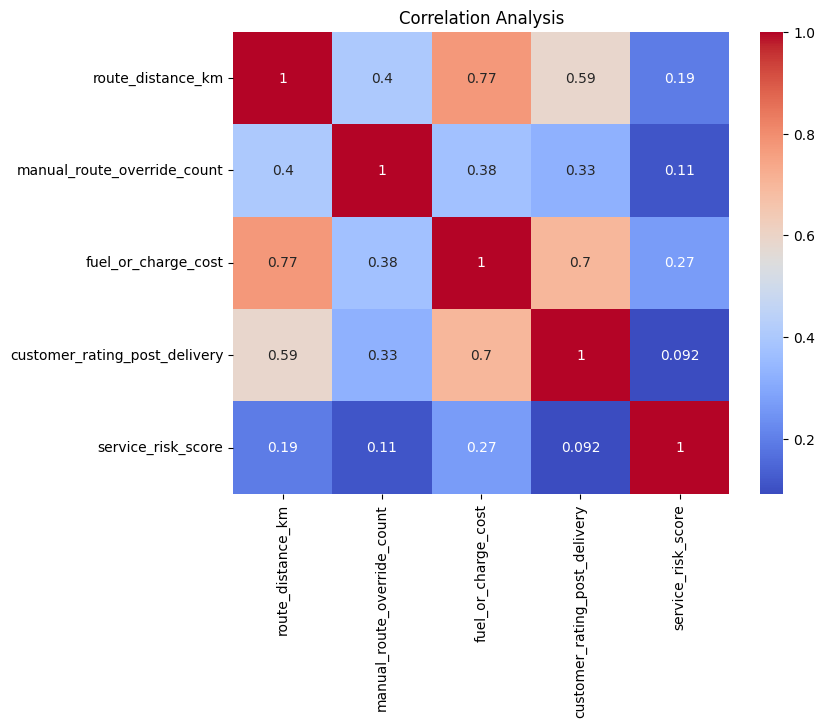

In [ ]:
import seaborn as sns

corr_data = cleaned[[
    "route_distance_km",
    "manual_route_override_count",
    "fuel_or_charge_cost",
    "customer_rating_post_delivery",
    "service_risk_score"
]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_data, annot=True, cmap="coolwarm")
plt.title("Correlation Analysis")
plt.show()

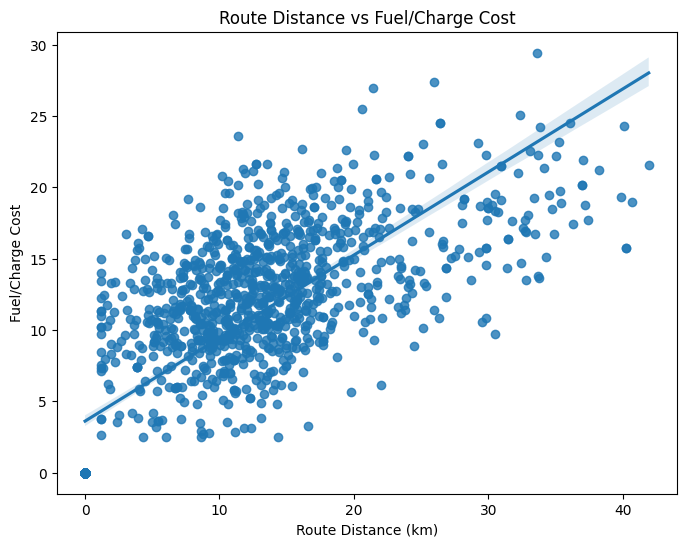

In [ ]:
plt.figure(figsize=(8,6))
sns.regplot(data=cleaned, x="route_distance_km", y="fuel_or_charge_cost")
plt.title("Route Distance vs Fuel/Charge Cost")
plt.xlabel("Route Distance (km)")
plt.ylabel("Fuel/Charge Cost")
plt.show()

In [ ]:
import pandas as pd
import numpy as np

base_url = "https://raw.githubusercontent.com/oshaajayaweera/Databases-and-Analytics/main/"

customers = pd.read_csv(base_url + "customers.csv")
orders = pd.read_csv(base_url + "orders.csv")
deliveries = pd.read_csv(base_url + "deliveries.csv")
drivers = pd.read_csv(base_url + "drivers.csv")
vehicles = pd.read_csv(base_url + "vehicles.csv")
hubs = pd.read_csv(base_url + "hubs.csv")
complaints = pd.read_csv(base_url + "complaints.csv")
incidents = pd.read_csv(base_url + "incidents.csv")
app_events = pd.read_csv(base_url + "app_events.csv")
data_dictionary = pd.read_csv(base_url + "data_dictionary.csv")

In [ ]:
data_dictionary

,file_name,record_count,description
0,hubs.csv,8,Operational hubs and control points
1,customers.csv,650,Customer master data with engagement and loyal...
2,drivers.csv,170,Driver workforce data with training and rating...
3,vehicles.csv,120,Fleet asset data including battery and mainten...
4,orders.csv,1250,Service orders across mobility and logistics o...
5,deliveries.csv,950,Operational dispatch and completion outcomes
6,incidents.csv,280,Delivery and asset incident records
7,complaints.csv,320,Customer complaints and compensation handling
8,app_events.csv,640,Digital platform events suitable for MongoDB r...


In [ ]:
zone_checks = {}

if "home_zone" in customers.columns:
    zone_checks["customers.home_zone"] = sorted(customers["home_zone"].dropna().astype(str).unique())

if "pickup_zone" in orders.columns:
    zone_checks["orders.pickup_zone"] = sorted(orders["pickup_zone"].dropna().astype(str).unique())

if "dropoff_zone" in orders.columns:
    zone_checks["orders.dropoff_zone"] = sorted(orders["dropoff_zone"].dropna().astype(str).unique())

if "base_zone" in drivers.columns:
    zone_checks["drivers.base_zone"] = sorted(drivers["base_zone"].dropna().astype(str).unique())

if "assigned_zone" in vehicles.columns:
    zone_checks["vehicles.assigned_zone"] = sorted(vehicles["assigned_zone"].dropna().astype(str).unique())

if "zone" in hubs.columns:
    zone_checks["hubs.zone"] = sorted(hubs["zone"].dropna().astype(str).unique())

for k, v in zone_checks.items():
    print(f"\n{k}")
    print(v)


customers.home_zone
['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']

orders.pickup_zone
['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']

orders.dropoff_zone
['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']

drivers.base_zone
['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']

vehicles.assigned_zone
['AIRPORT', 'Airport', 'CENTRAL', 'Central', 'Ctr', 'EAST', 'East', 'NORTH', 'North', 'RiverSide', 'Riverside', 'SOUTH', 'South', 'WEST', 'West', 'north']

hubs.zone
['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']


In [ ]:
merged = orders.merge(deliveries, on="order_id", how="left") \
               .merge(hubs, on="hub_id", how="left", suffixes=("", "_hub")) \
               .merge(complaints, on="order_id", how="left", suffixes=("", "_complaint")) \
               .merge(incidents, on="delivery_id", how="left", suffixes=("", "_incident"))

In [ ]:
cleaned = merged.copy()

for col in cleaned.columns:
    if cleaned[col].dtype == "object":
        cleaned[col] = cleaned[col].fillna("Not Available")

for col in cleaned.select_dtypes(include=[np.number]).columns:
    cleaned[col] = cleaned[col].fillna(0)

In [ ]:
cleaned["is_failed"] = (cleaned["delivery_status"] == "Failed").astype(int)
cleaned["is_delayed"] = (cleaned["delivery_status"] == "Delayed").astype(int)
cleaned["has_complaint"] = (cleaned["complaint_id"] != "Not Available").astype(int)
cleaned["has_incident"] = (cleaned["incident_id"] != "Not Available").astype(int)

In [ ]:
cleaned["service_risk_score"] = (
    cleaned["is_failed"] * 3 +
    cleaned["is_delayed"] * 2 +
    cleaned["has_complaint"] * 2 +
    cleaned["has_incident"] * 1
)

In [ ]:
cleaned["risk_category"] = np.where(
    cleaned["service_risk_score"] >= 5, "High",
    np.where(cleaned["service_risk_score"] >= 3, "Medium", "Low")
)

In [ ]:
risk_view = cleaned[[
    "order_id",
    "delivery_id",
    "hub_id",
    "delivery_status",
    "is_failed",
    "is_delayed",
    "has_complaint",
    "has_incident",
    "service_risk_score",
    "risk_category"
]].head(20)

risk_view

,order_id,delivery_id,hub_id,delivery_status,is_failed,is_delayed,has_complaint,has_incident,service_risk_score,risk_category
0,O00001,DL00937,H01,OnTime,0,0,0,0,0,Low
1,O00002,Not Available,Not Available,Not Available,0,0,0,0,0,Low
2,O00003,DL00925,H02,Delayed,0,1,1,0,4,Medium
3,O00004,DL00002,H02,OnTime,0,0,0,0,0,Low
4,O00005,DL00671,H03,OnTime,0,0,1,0,2,Low
5,O00006,Not Available,Not Available,Not Available,0,0,0,0,0,Low
6,O00007,DL00120,H06,Delayed,0,1,1,0,4,Medium
7,O00008,DL00201,H03,OnTime,0,0,1,0,2,Low
8,O00009,DL00042,H01,OnTime,0,0,0,1,1,Low
9,O00010,DL00032,H08,OnTime,0,0,0,1,1,Low
